In [88]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Dataset: Read

In [89]:
FILE_ID = "1PPp0KKJ7wBMex3loW0dAruk_6cBaztPY"

url = f"https://drive.google.com/uc?export=download&id={FILE_ID}"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1529, 22)


,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,171.0,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,183.0,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY


# Dataset Overview

In [90]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print("\nTarget distributions:")
display(df["CVD Risk Level"].value_counts())

Rows: 1529
Columns: 22

Data types:


,dtype
Sex,object
Age,float64
Weight (kg),float64
Height (m),float64
BMI,float64
Abdominal Circumference (cm),float64
Blood Pressure (mmHg),object
Total Cholesterol (mg/dL),float64
HDL (mg/dL),float64
Fasting Blood Sugar (mg/dL),float64



Duplicate rows: 0

Missing values:


,missing_count
Diastolic BP,82
Weight (kg),81
HDL (mg/dL),80
Waist-to-Height Ratio,79
Age,78
Height (cm),74
Total Cholesterol (mg/dL),73
Systolic BP,71
CVD Risk Score,70
Estimated LDL (mg/dL),69



Target distributions:


,count
CVD Risk Level,
HIGH,728
INTERMEDIARY,581
LOW,220


# Data Cleaning & Feature Recovery

In [91]:
data = df.copy()

# Recover systolic/diastolic BP from the complete BP string where needed.
bp_parts = data["Blood Pressure (mmHg)"].str.extract(r"(?P<bp_sys>\d+(?:\.\d+)?)/(?P<bp_dia>\d+(?:\.\d+)?)")
bp_sys = pd.to_numeric(bp_parts["bp_sys"], errors="coerce")
bp_dia = pd.to_numeric(bp_parts["bp_dia"], errors="coerce")

data["Systolic BP"] = data["Systolic BP"].fillna(bp_sys)
data["Diastolic BP"] = data["Diastolic BP"].fillna(bp_dia)

# Recover height in meters from height in centimeters where possible.
data["Height (m)"] = data["Height (m)"].fillna(data["Height (cm)"] / 100)

# Invalid negative LDL is not physiologically meaningful.
data.loc[data["Estimated LDL (mg/dL)"] < 0, "Estimated LDL (mg/dL)"] = np.nan

# Recalculate BMI only when missing and the required measurements exist.
bmi_calc = data["Weight (kg)"] / (data["Height (m)"] ** 2)
data["BMI"] = data["BMI"].fillna(bmi_calc)

# Remove duplicate/target columns.
target_reg = "CVD Risk Score"
target_cls = "CVD Risk Level"

drop_cols = [
    target_reg,
    target_cls,
    "Blood Pressure (mmHg)",
    "Height (cm)"
]

X = data.drop(columns=drop_cols)
y_reg = data[target_reg]
y_cls = data[target_cls]

print("Features used:", X.columns.tolist())
print("\nRemaining missing values in features:")
display(X.isnull().sum().sort_values(ascending=False).to_frame("missing"))

Features used: ['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Blood Pressure Category', 'Estimated LDL (mg/dL)']

Remaining missing values in features:


,missing
Estimated LDL (mg/dL),82
Weight (kg),81
HDL (mg/dL),80
Waist-to-Height Ratio,79
Age,78
Total Cholesterol (mg/dL),73
Fasting Blood Sugar (mg/dL),67
Abdominal Circumference (cm),67
Height (m),6
BMI,5


# EDA (Numerical Features)

,count,mean,std,min,25%,50%,75%,max
Age,1451.0,47.025500,12.421063,25.00,37.000,46.0000,55.00000,79.000
Weight (kg),1448.0,85.917427,21.012580,50.10,67.050,86.6145,105.00000,120.000
Height (m),1523.0,1.753834,0.112701,1.50,1.660,1.7570,1.84200,2.000
BMI,1524.0,28.417471,7.033652,15.00,22.600,28.1445,33.90000,46.200
Abdominal Circumference (cm),1462.0,91.773214,12.823573,70.00,80.500,91.6000,102.26900,119.996
Total Cholesterol (mg/dL),1456.0,198.539148,57.794099,100.00,150.000,197.0000,249.00000,300.000
HDL (mg/dL),1449.0,56.197378,16.066754,30.00,42.000,56.0000,70.00000,89.000
Fasting Blood Sugar (mg/dL),1462.0,117.485636,30.289174,70.00,92.000,115.0000,138.00000,198.000
Height (cm),1455.0,175.390600,11.251527,150.00,166.000,175.6940,184.20850,199.960
Waist-to-Height Ratio,1450.0,0.525727,0.081213,0.36,0.460,0.5220,0.58375,0.787


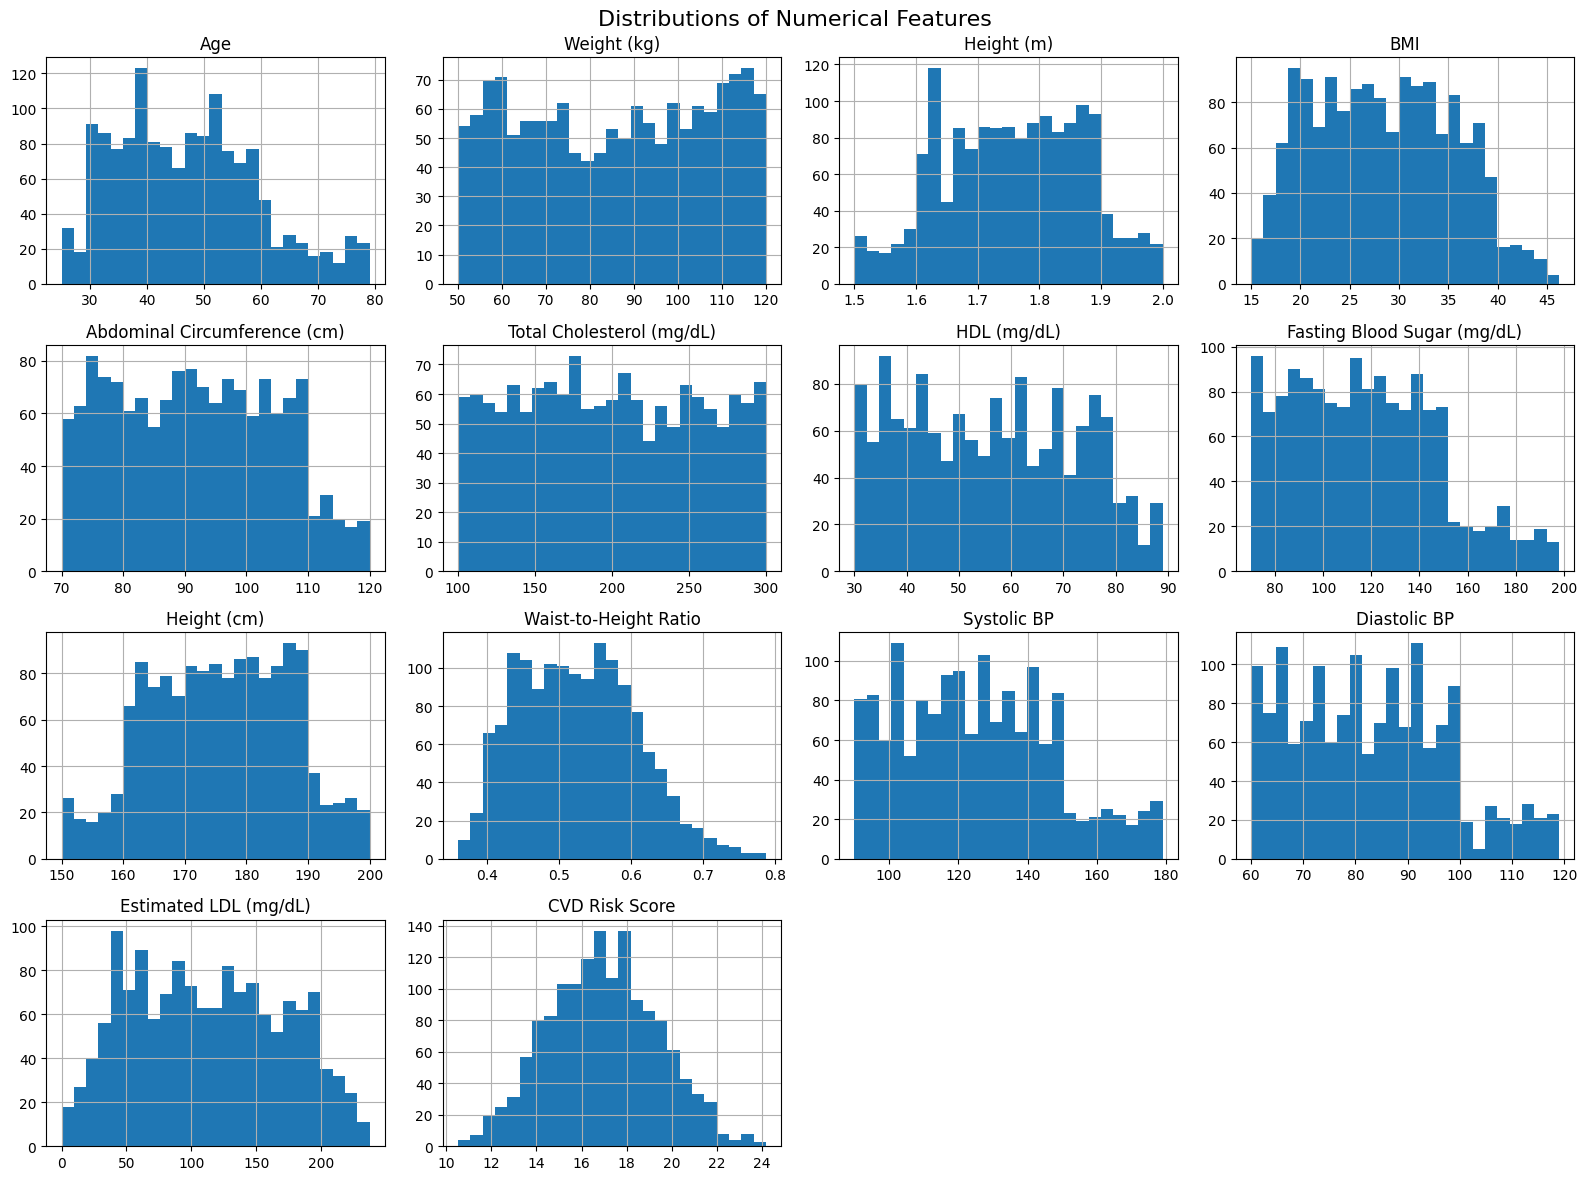

In [92]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
display(data[numeric_cols].describe().T)

# Histograms
data[numeric_cols].hist(figsize=(16, 12), bins=25)
plt.suptitle("Distributions of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

# EDA (Categorical Features and Targets)


Sex


,count
Sex,
F,773
M,756



Blood Pressure (mmHg)


,count
Blood Pressure (mmHg),
113/77,4
114/63,4
127/84,4
113/79,4
148/98,3
...,...
120/97,1
93/73,1
96/71,1



Smoking Status


...

,count
Family History of CVD,
N,780
Y,749



Blood Pressure Category


,count
Blood Pressure Category,
Hypertension Stage 2,632
Hypertension Stage 1,497
Normal,300
Elevated,100



CVD Risk Level


,count
CVD Risk Level,
HIGH,728
INTERMEDIARY,581
LOW,220


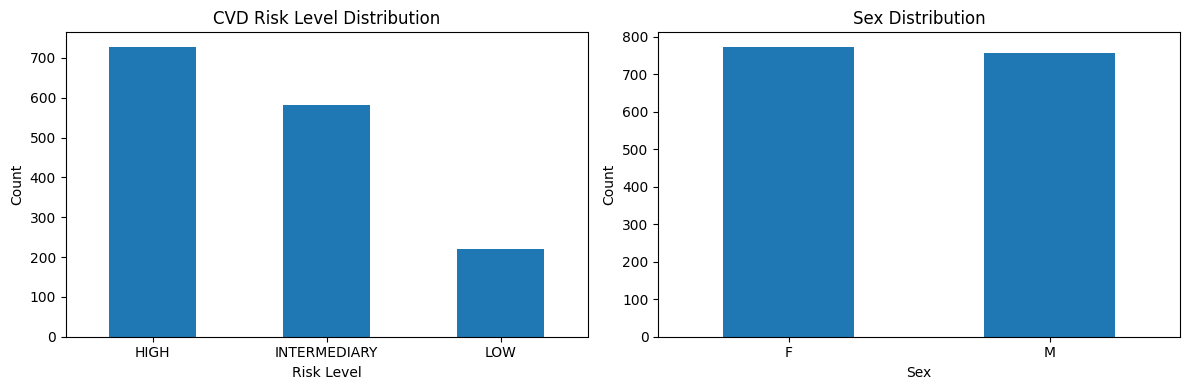

In [93]:
categorical_cols = data.select_dtypes(exclude=np.number).columns.tolist()

for col in categorical_cols:
    print(f"\n{col}")
    display(data[col].value_counts(dropna=False).to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data["CVD Risk Level"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("CVD Risk Level Distribution")
axes[0].set_xlabel("Risk Level")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

data["Sex"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Sex Distribution")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# EDA Correlation with the Numerical Target

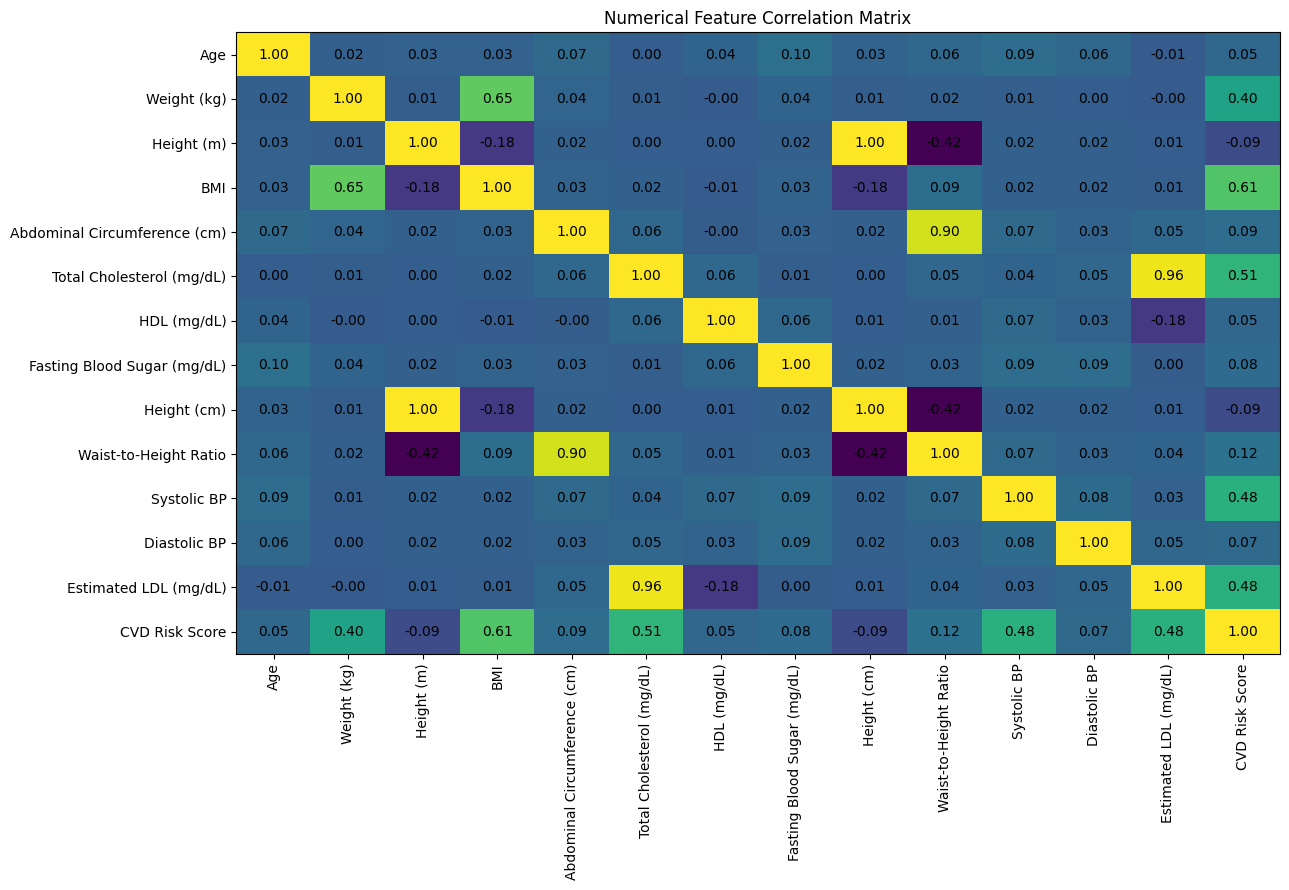

In [94]:
corr = data[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(13, 9))
plt.imshow(corr, aspect="auto")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

# Add correlation values [each cell]
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()